In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

<function matplotlib.pyplot.show(close=None, block=None)>

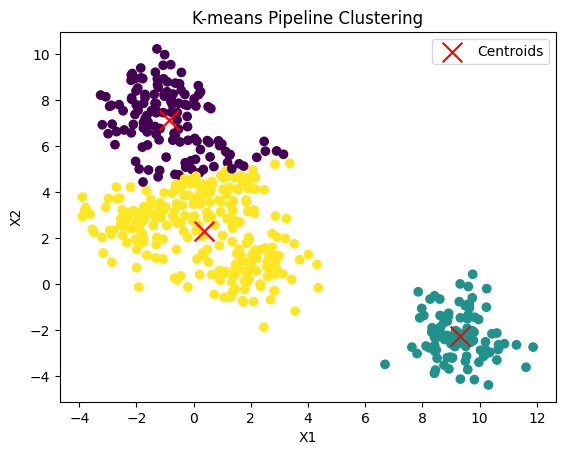

In [5]:
X = pd.read_csv("cluster_data.csv").values 
scalar = StandardScaler()
pipeline = Pipeline([
    ('scaler',scalar),
    ('kmeans',KMeans(n_clusters=3, init='k-means++'))
    ])
pipeline.fit(X)
labels = pipeline.named_steps['kmeans'].labels_
scaled_centroids = pipeline.named_steps['kmeans'].cluster_centers_
centroids = scalar.inverse_transform(scaled_centroids)
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', marker='o')
plt.scatter(centroids[:,0], centroids[:,1], c='red', marker='x', s=200, label='Centroids')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('K-means Pipeline Clustering')
plt.legend()
plt.show

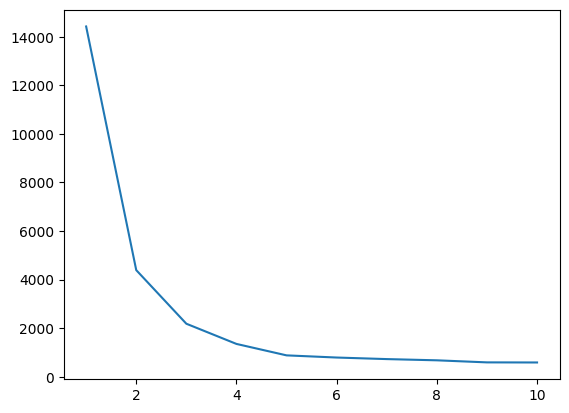

In [6]:
X = pd.read_csv("cluster_data.csv").values 
wcss = []
for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss)
plt.show()